# 5 Modeling<a id='5_Modeling'></a>

## 5.1 Contents<a id='5.1_Contents'></a>
* [5 Modeling](#5_Modeling)
  * [5.1 Contents](#5.1_Contents)
  * [5.2 Introduction](#5.2_Introduction)
  * [5.3 Imports](#5.3_Imports)
  * [5.4 Load Data](#5.4_Load_Data)
  * [5.5 Linear Regression Model (Ridge)](#5.5_Linear_Regression_Model_(Ridge))
    * [5.5.1 TimeSeries Split Setup](#5.5.1_TimeSeries_Split_Setup)
    * [5.5.2 Pipeline Construction](#5.5.2_Pipeline_Construction)
    * [5.5.3 GridSearchCV Hyperparameter Tuning](#5.5.3_GridSearchCV_Hyperparameter_Tuning)
    * [5.5.4 Model Prediction & Evaluation](#5.5.4_Model_Prediction_&_Evaluation)
    * [5.5.5 Feature_Importance_Assessment](#5.5.5_Feature_Importance_Assessment)
    * [5.5.6 Residuals Analysis](#5.5.6_Residuals_Analysis)
  * [5.6 KMeans Clustering Model](#5.6_KMeans_Clustering_Model)
    * [5.6.1 County Level Datase](#5.6.1_County_Level_Dataset)
    * [5.6.2 Clusters Determination](#5.6.2_Clusters_Determination)
    * [5.6.3 KMeans Model Fitting](#5.6.3_KMeans_Model_Fitting)
    * [5.6.4 Clusters Analysis](#5.6.4_Clusters_Analysis)
    * [5.6.5 County Segmentation & Takeaways](#5.6.5_County_Segmentation_&_Takeaways)
  * [5.7 Combined Insights (Ridge Regression + KMeans Clustering)](#5.7_Combined_Insights_Ridge_Regression_+_KMeans_Clustering)
  * [5.8 Summary & Recommendations](#5.8_Summary_&_Recommendations)

## 5.2. Introduction<a id='5.2_Introduction'></a>

In the previous notebook, we created and standardized time based train/test sets for Linear Regression Modeling and dataset for KMeans Modeling spanning time period between 2017-2025. All datasets have county and year from Washington state data as the reference variables.

In this notebook, we will model for both approaches

1. Linear Regression Model : To determine key factors driving EV adoption rate.
2. KMeans Clustering Model : To determine which counties need to be prioritized for EV infrastructure and policy initiatives.

We will also try to explore what factors determine county prioritization for EV adoption.

##  5.3 Imports<a id='5.3_Imports'></a>

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve, TimeSeriesSplit
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,silhouette_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime
from library.sb_utils import save_file
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 5.4 Load Data<a id='5.4_Load_Data'></a>

In [2]:
#Datasets for modeling
lr_train = pd.read_csv('../data/processed/ev_lr_train_scaled.csv')
lr_test = pd.read_csv('../data/processed/ev_lr_test_scaled.csv')
km_data = pd.read_csv('../data/processed/ev_km_scaled.csv')
#Lets also load the original processed ev dataset from data wrangling phase for better cluster interpretation with KMeans
ev_orig = pd.read_csv('../data/processed/final_ev_info_dataset.csv')

In [3]:
lr_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   273 non-null    object 
 1   year                     273 non-null    int64  
 2   log_median_income        273 non-null    float64
 3   log_ev_adoption_lag      273 non-null    float64
 4   log_ev_charging_density  273 non-null    float64
 5   lag_missing_flag         273 non-null    float64
 6   log_ev_adoption_rate     273 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 15.1+ KB


In [4]:
lr_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   78 non-null     object 
 1   year                     78 non-null     int64  
 2   log_median_income        78 non-null     float64
 3   log_ev_adoption_lag      78 non-null     float64
 4   log_ev_charging_density  78 non-null     float64
 5   lag_missing_flag         78 non-null     float64
 6   log_ev_adoption_rate     78 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 4.4+ KB


In [5]:
km_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   351 non-null    object 
 1   year                     351 non-null    int64  
 2   log_median_income        351 non-null    float64
 3   log_ev_charging_density  351 non-null    float64
 4   log_ev_adoption_rate     351 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 13.8+ KB


In [6]:
#features and target variables' definitions
target = 'log_ev_adoption_rate'
# Linear Regression Features
lr_features = ['log_median_income','log_ev_adoption_lag','log_ev_charging_density','lag_missing_flag']
#KMeans Features
km_features = ['log_median_income','log_ev_charging_density'] 

## 5.5 Linear Regression Model (Ridge)<a id='5.5_Linear_Regression_Model_(Ridge)'></a>

For Linear Regression Modeling, Ridge will be used instead of Ordinary Least Squares because we have a small test set with 78 samples and Ridge handles overfitting through regularization better than OLS. GridSearchCV will help tune the regularization strength and Ridge will also keep all 4 features while proportionally shrinking their coefficients.

### 5.5.1 TimeSeries Split Up<a id='5.5.1_TimeSeries_Split_Up'></a>

Our datasets contain time series data with county year records ranging from 2017 to 2025. TimeSeries split handles temporal ordering for train test splits in the correct manner. With kfold cross validation we could shuffle time periods allowing future data leakage into training on historical predictions. Hence, TimeSeries Split up is used in this case instead of random cross validation.

In [7]:
#Get Train Test Features and Target Variable
X_train_lr = lr_train[lr_features]
y_train_lr = lr_train[target]
X_test_lr = lr_test[lr_features]
y_test_lr = lr_test[target]

In [8]:
#time series split for cross validation
tscv = TimeSeriesSplit(n_splits=5)
tscv.n_splits

5

### 5.5.2 Pipeline Construction<a id='5.5.2_Pipeline_Construction'></a>

Next, pipeline will be created to chain preprocessing and ridge modeling steps together

In [9]:
lr_pipeline = Pipeline([
               ('ridge', Ridge(alpha=1)) #default alpha to be tunes in GridSearchCV step
               ])              

### 5.5.3 GridSearchCV Hyperparameter Tuning <a id='5.5.3_GridSearchCV_Hyperparameter_Tuning'></a>

In [10]:
#Define parameter grid and fit using GridSearchCV
paramgrid = { 'ridge__alpha' : [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
#Fit GridSearchCV
grid_search = GridSearchCV(
                           lr_pipeline,
                           paramgrid,
                           cv=tscv,
                           scoring ='r2',
                           n_jobs=-1,
                           verbose = 1
                           )
grid_search.fit(X_train_lr, y_train_lr)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('ridge', Ridge(alpha=1))]), n_jobs=-1,
             param_grid={'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='r2', verbose=1)

In [11]:
print(f"Best alpha : {grid_search.best_params_['ridge__alpha']}")
print(f"Best CV R2 score : {grid_search.best_score_: .4f}")

Best alpha : 0.1
Best CV R2 score :  0.9437


### 5.5.4 Model Prediction & Evaluation <a id='5.5.4_Model_Prediction_&_Evaluation'></a>

In [12]:
#predict the model
y_train_pred = grid_search.best_estimator_.predict(X_train_lr)
y_test_pred = grid_search.best_estimator_.predict(X_test_lr)

In [13]:
#calculate metrics
#r2
train_r2 = r2_score(y_train_lr, y_train_pred)
test_r2 = r2_score(y_test_lr, y_test_pred)
#rmse
train_rmse = np.sqrt(mean_squared_error(y_train_lr, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_lr, y_test_pred))
#mae
train_mae = mean_absolute_error(y_train_lr, y_train_pred)
test_mae = mean_absolute_error(y_test_lr, y_test_pred)

print(f'Final Ridge Regression Model Performance of Test Set (2024-2025)') 
print(f'Train Set r2 : {train_r2}')
print(f'Test Set r2 : {test_r2}')
print(f'Train Set rmse : {train_rmse}')
print(f'Test Set rmse : {test_rmse}')
print(f'Train Set mae : {train_mae}')
print(f'Test Set mae : {test_mae}')

Final Ridge Regression Model Performance of Test Set (2024-2025)
Train Set r2 : 0.9683796104054785
Test Set r2 : 0.9779056157422771
Train Set rmse : 0.06084111292057276
Test Set rmse : 0.06702855967804011
Train Set mae : 0.03941412300694596
Test Set mae : 0.051310499021481826


The Ridge regressions model shows a strong performance on the test set for 2024-2025 data with an R2 of ~0.98 explaining ~98% of adoption rate variance. 
Test RMSE of 0.067 & MAE of 0.05 are very low indicating predicted values are close to actual values.
This model could be helpful in forecasting county level EV adoption and understanding EV infrastructure investments and policy impacts.

### 5.5.5 Feature Importance Assessment <a id='5.5.5_Feature_Importance_Assessment'></a>

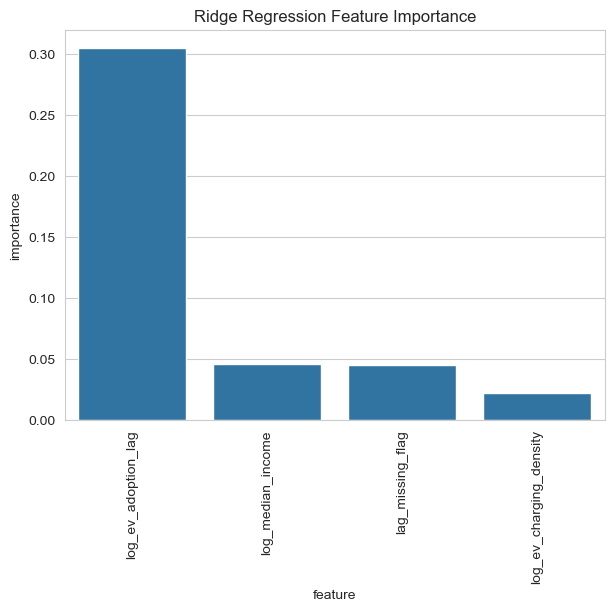

In [14]:
#assessing feature importance with ridge regression model
ridge_model = grid_search.best_estimator_
coef = ridge_model.named_steps['ridge'].coef_
features = lr_features
ridge_feature_imp = pd.DataFrame({'feature': features, 'coefficient': coef, 'importance':np.abs(coef)}).sort_values(by='importance',ascending=False)
_=sns.barplot(ridge_feature_imp, x='feature', y='importance')
plt.title("Ridge Regression Feature Importance")
plt.tight_layout()
imagepath = '../reports/figures'
image_path = os.path.join(imagepath, 'ridge_feature_imp_plot_w_population.png')
plt.xticks(rotation=90)
plt.savefig(image_path, dpi = 300, bbox_inches='tight')

Ridge Regression model feature importance was evaluated using standardized coefficients.

1. Previous years’ adoption rate dominates EV adoption prediction rate. However, it is not the most actionable insight. 
2. Median Income slightly outweighs EV charging infrastructure suggesting investing in infrastructure alone will not lead to adoption without supporting socioeconomic conditions. 
3. For EV policies and infrastructure prioritization, high income counties with infrastructure gaps that have low adoption rates should be the prime focus.

### 5.5.6 Residuals Analysis<a id='5.5.6_Residuals_Analysis'></a>

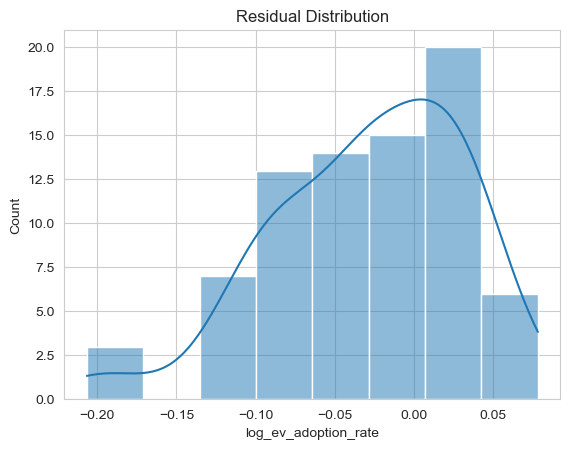

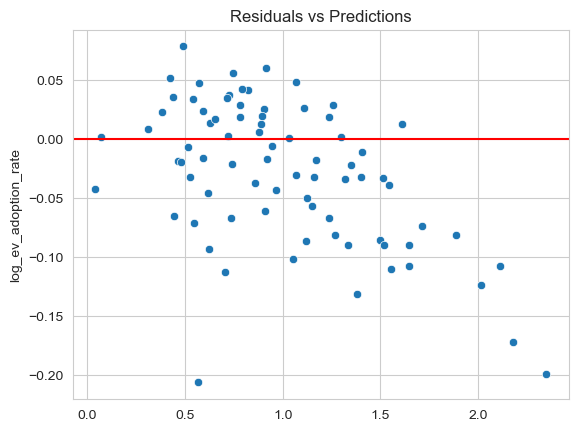

In [15]:
residuals = y_test_lr - y_test_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

sns.scatterplot(x=y_test_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions")
plt.show()

1. Residuals are centered around zero indicating the model is not majorly overpredicting or underpredicting. 
2. However, there is heteroscedasticity and a funneling pattern indicating variance is not perfectly constant.
3. The downward trend in the residuals vs. Predictions chart suggests that the model may slightly over predict for higher values and underpredict for lower values. Few points deviate strongly but overall but there are not many like that to destabilize the model.
4. The residual distribution is roughly bell shaped with slight skewness, suggesting residuals are well behaved for most part and model is stable.

The model provides a decent fit for the data with minor deviations from ideal assumptions. There is some evidence of non-linearity and variance instability, but overall it performs well and captures the main signal effectively.

## 5.6 KMeans Clustering Model<a id='5.6_KMeans_CLustering_Model'></a>

### 5.6.1 County Level Dataset<a id='5.6.1_County_Level_Dataset'></a>

The model dataset is at county/year level and for KMeans Clustering we need it at the county level. So, lets get the data at the county level.

In [16]:
#Latest snapshot for each county
county_df = km_data.sort_values('year').groupby('county').last().reset_index()
#county_df = km_data.groupby('county').mean().reset_index()
county_df.head(50)

,county,year,log_median_income,log_ev_charging_density,log_ev_adoption_rate
0,Adams,2025,0.120529,1.539692,0.447641
1,Asotin,2025,0.518561,0.389271,0.474417
2,Benton,2025,1.586127,1.653084,1.073446
3,Chelan,2025,1.014443,2.191142,1.186721
4,Clallam,2025,0.666556,1.835501,1.167783
5,Clark,2025,2.019492,0.699020,1.555792
6,Columbia,2025,0.221099,1.828723,0.493140
7,Cowlitz,2025,0.830076,-0.234443,0.900229
8,Douglas,2025,0.725025,0.390552,0.922391
9,Ferry,2025,-0.331947,1.505948,0.590338


In [17]:
county_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   39 non-null     object 
 1   year                     39 non-null     int64  
 2   log_median_income        39 non-null     float64
 3   log_ev_charging_density  39 non-null     float64
 4   log_ev_adoption_rate     39 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1.7+ KB


### 5.6.2 Clusters Determination<a id='5.6.2_Clusters_Determination'></a>

Let's determine the optimal number of clusters.

In [18]:
X_km = county_df[km_features]

#Elbow method and Silhouette analysis to dtermine optimal number of clusters
inertias = []
silhouette_scores = []
K_range = range(2,11)

for k in K_range:
    eval_pipeline = Pipeline([
        ('kmeans', KMeans(n_clusters = k, random_state = 42, n_init = 10))
    ])
    eval_pipeline.fit(X_km)
    inertias.append(eval_pipeline.named_steps['kmeans'].inertia_)
    silhouette_scores.append(silhouette_score(X_km, eval_pipeline.named_steps['kmeans'].labels_))

print('\nKMeans Evaluations')
print(f"{'K':>3} {'Inertia':>12} {'Silhouette' :>12}")   
for k, inertia, sil_score in zip(K_range, inertias, silhouette_scores):
    print(f"{k:3d} {inertia: 12.2f} {sil_score: 12.4f}")
#Best K
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal k : {best_k}")


KMeans Evaluations
  K      Inertia   Silhouette
  2        32.20       0.3351
  3        19.72       0.3934
  4        14.15       0.3910
  5        11.35       0.3936
  6         9.00       0.3894
  7         7.35       0.3738
  8         5.40       0.3647
  9         4.58       0.3517
 10         4.01       0.2991

Optimal k : 5


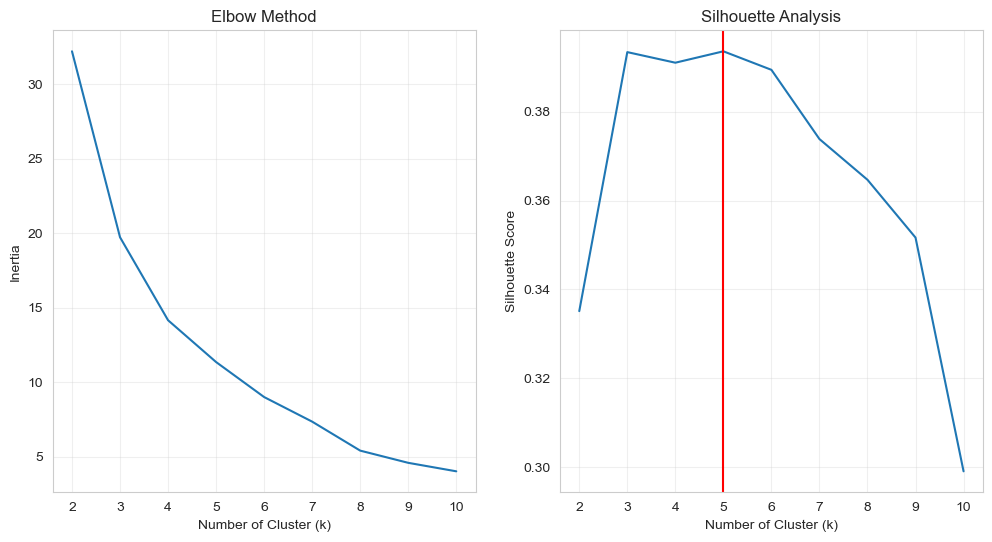

In [19]:
#Determine Best k using elbow method
fig, axes = plt.subplots(1,2,figsize=(12,6))
axes[0].plot(K_range, inertias)
axes[0].set_xlabel("Number of Cluster (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].grid(alpha=0.3)
axes[1].plot(K_range, silhouette_scores)
axes[1].axvline(best_k, color = 'red', label = f'Optimal k: {best_k}')
axes[1].set_xlabel("Number of Cluster (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")
axes[1].grid(alpha=0.3)

Based on the elbow plot above, k=3,4,5 all look like good selections for k value with the line having a more linear slope after that. In this case,we will pick optimal k of 5 suggested by the algorithm as the silhouette analysis also has a peak at 5 before going downwards.

### 5.6.3 KMeans Model Fitting<a id='5.6.3_KMeans_Model_Fitting'></a>

In [20]:

final_km_pipeline = Pipeline([
        ('kmeans', KMeans(n_clusters = best_k, random_state = 42, n_init = 10))
    ])
#fit kmeans model with optimal k of 3
#kmeans_model = KMeans(n_clusters = best_k, random_state = 42, n_init = 10)
cluster_labels = final_km_pipeline.fit_predict(X_km)
county_df['cluster']=cluster_labels
print(f"\nCluster Distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())


Cluster Distribution:
0     7
1    13
2     9
3     1
4     9
Name: count, dtype: int64


### 5.6.4 Clusters Analysis<a id='5.6.4_Clusters_Analysis'></a>

In [21]:
cluster_summary = county_df.groupby('cluster').agg({
    'log_median_income' : 'mean',
    'log_ev_charging_density' : 'mean',
    'log_ev_adoption_rate' : ['mean', 'min', 'max'],
    'county' : 'count'
    }).round(4)

cluster_summary.columns = ['Avg_Income','Avg_EV_Charging_Density','Avg_Adoption','Min_Adoption','Max_Adoption','County_Count']
print(cluster_summary)

         Avg_Income  Avg_EV_Charging_Density  Avg_Adoption  Min_Adoption  \
cluster                                                                    
0            2.1654                   0.8969        1.5930        1.2465   
1            1.0745                   1.6545        1.2164        0.8236   
2           -0.0926                   1.4446        0.6529        0.4476   
3            0.2172                  -1.4649        0.0727        0.0727   
4            0.7846                   0.2728        0.8529        0.4744   

         Max_Adoption  County_Count  
cluster                              
0              2.1499             7  
1              2.0076            13  
2              0.9416             9  
3              0.0727             1  
4              1.5069             9  


Lets recover and use original features without log transformations for better interpretability of clusters.

In [22]:
#ev_county_df = ev_orig[['county','median_income','ev_charging_density','ev_adoption_rate']].groupby('county').mean().reset_index()
ev_county_df = ev_orig.sort_values('year').groupby('county').last().reset_index()
county_df_w_orig = county_df[['county','cluster']].merge(ev_county_df, on =['county'], how='left')
county_df_w_orig.head()

,county,cluster,year,total_registered_vehicles,registered_electric_vehicles,bev_ratio_within_ev,cafv_eligibility_rate,median_income,population,ev_charging_stations,ev_adoption_rate,ev_growth_rate,has_growth,new_ev_purchase_ratio,ev_adoption_lag,lag_missing_flag,high_adoption,adoption_segment,income_per_vehicle,ev_charging_density
0,Adams,2,2025,14346,81,0.857143,1.000000,69332,21550,9,0.564617,50.000000,1,17.283951,0.372977,0,0,medium,4.832845,0.041763
1,Asotin,4,2025,12519,76,0.750000,0.916667,75647,22750,4,0.607077,16.923077,1,15.789474,0.496239,0,0,medium,6.042575,0.017582
2,Benton,1,2025,148797,2865,0.731602,0.948052,95572,219625,99,1.925442,35.205286,1,16.125654,1.419723,0,1,high,0.642298,0.045077
3,Chelan,1,2025,58164,1324,0.773333,0.968889,84325,82900,53,2.276322,23.738318,1,16.993958,1.825166,0,1,high,1.449780,0.063932
4,Clallam,1,2025,51606,1143,0.802030,0.989848,78139,78650,40,2.214859,20.189274,1,17.235346,1.806427,0,1,high,1.514146,0.050858


In [23]:
cluster_summary_orig = county_df_w_orig.groupby('cluster').agg({
    'median_income' : 'mean',
    'ev_charging_density' : 'mean',
    'ev_adoption_rate' : ['mean', 'min', 'max'],
    'county' : 'count'
    }).round(4)

cluster_summary_orig.columns = ['Avg_Income','Avg_EV_Charging_Density','Avg_Adoption','Min_Adoption','Max_Adoption','County_Count']
print(cluster_summary_orig)

          Avg_Income  Avg_EV_Charging_Density  Avg_Adoption  Min_Adoption  \
cluster                                                                     
0        108898.4286                   0.0283        4.1254        2.4781   
1         85687.6923                   0.0477        2.5663        1.2786   
2         66304.2222                   0.0397        0.9515        0.5646   
3         70815.0000                   0.0000        0.0754        0.0754   
4         80409.5556                   0.0162        1.4659        0.6071   

         Max_Adoption  County_Count  
cluster                              
0              7.5843             7  
1              6.4451            13  
2              1.5641             9  
3              0.0754             1  
4              3.5127             9  


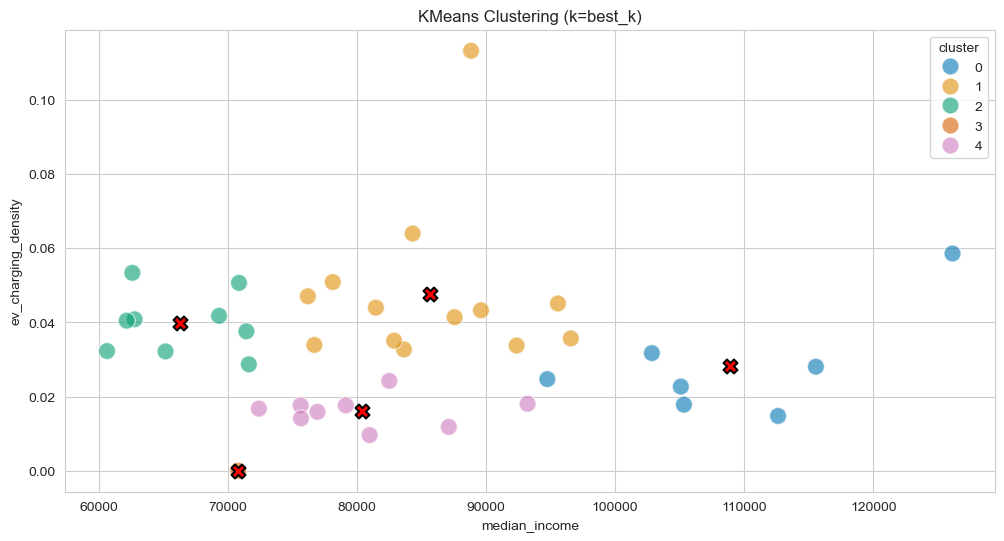

In [29]:
#Cluster Visualization
#create scatter plot with features
plt.figure(figsize=(12,6))
sns.scatterplot(data = county_df_w_orig, x='median_income', y='ev_charging_density', hue = 'cluster', palette = 'colorblind', s=150, alpha=0.6)

orig_centroids = county_df_w_orig.groupby('cluster')[['median_income','ev_charging_density']].mean()
#add centroids next
plt.scatter(orig_centroids['median_income'], orig_centroids['ev_charging_density'], marker='X', s=100, c='red',edgecolors='black',
    linewidths=1.5)
plt.title("KMeans Clustering (k=best_k)")
plt.show()

##### Cluster 0 (Blue):
•	County Profile: These are the highest income counties with approx. dollar 109K median income, but a relatively low charging density (approx. 0.03). <p>
•	Key Takeaway: These counties represent more purchasing power. EV adoption here is happening naturally because residents can afford EV vehicles and are potentially charging at home. Although they seem to have public infrastructure gaps, most of the focus should be on expanding private commercial settings infrastructure instead of spending govt. resources on public EV charging stations.<p>
##### Cluster 1 (Mustard):
•	County Profile: These are also mid high income counties with approx. dollar 86K median income, the highest public EV charging density (approx. 0.05). <p>
•	Key Takeaway: These counties also represent more purchasing power. EV adoption here is happening naturally because residents can afford EV vehicles and there seem to be no public infrastructure gaps. Future investments here should focus on maintenance of existing infrastructure and more premium services like high-speed reliability of DC Fast Chargers.<p><p>
##### Cluster 2 (Green):
•	County Profile: This left most cluster has the lowest income range (approx. dollar 60K–73K) with a higher public EV charging density than most clusters at approx. 0.04. <p>
•	Key Takeaway: These seem to be rural or lower-income counties with enough public infrastructure. They are excellent candidates for govt. subsidies and grants on BEV vehicles to accelerate EV vehicles adoption.
##### Cluster 3 (Orange):
•	County Profile: This bottom most cluster with only one county (Garfield) seems like an outlier.Although, the median income is decent (approx. dollar 71K) and 0 EV infrastructure, indicating it might be rural and sparsely populated.<p>
•	Key Takeaway: Garfield county is rural with lower income, sparse population and minimal infrastructure. This is a special case that needs different handling from state government.
##### Cluster 4 (Lavender):
•	County Profile: This cluster represents middle to higher middle income (approx. dollar 80,000) counties with low baseline public EV charging density (approx. 0.016).<p>
•	Key Takeaway: These counties have a baseline infrastructure with residents starting to adopt EV's. These counties should be prioritized both for govt. subsidies on Electric Vehicles and public infrastructure expansion to encourage further adoption.

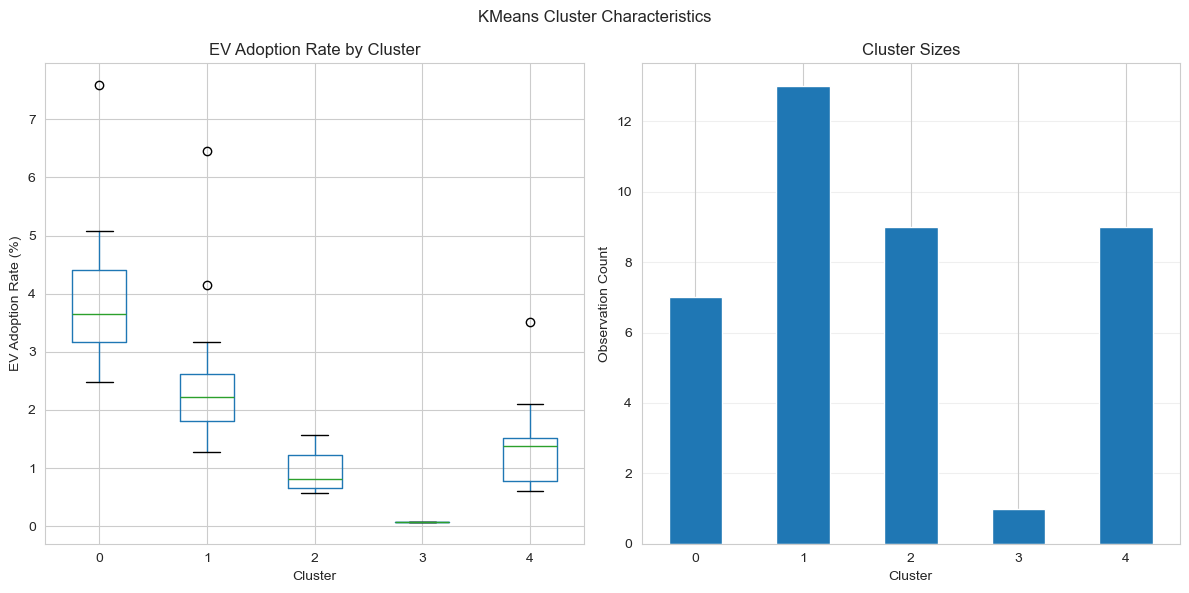

In [25]:
#boxplots for adoption rate by cluster
fig, axes = plt.subplots(1,2, figsize=(12,6))
county_df_w_orig.boxplot(column = 'ev_adoption_rate', by = 'cluster', ax = axes[0])
axes[0].set(xlabel = 'Cluster', ylabel = 'EV Adoption Rate (%)', title = 'EV Adoption Rate by Cluster')
axes[0].set_xticks(range(1, best_k + 1))
axes[0].set_xticklabels(range(best_k))

#bar chart
cluster_counts = county_df_w_orig['cluster'].value_counts().sort_index()
cluster_counts.plot(kind='bar', ax = axes[1], rot=0)
axes[1].set(xlabel = 'Cluster', ylabel = 'Observation Count', title = 'Cluster Sizes')
axes[1].grid(axis='y', alpha=0.3)
fig.suptitle("KMeans Cluster Characteristics")
plt.tight_layout()
plt.show()

Below are some insights based on these boxplots
##### High EV Adoption Rate (Clusters 0 & 1): 
Cluster 0 has the highest adoption rate (median ~3.7%), followed by Cluster 1 (median ~2.2%). Both clusters have higher adoption county outliers that are heavily outperforming other counties in these clusters. They also represent the highest percentage of counties (20 out of 39) in Washington state.
##### Medium EV Adoption Rate (Cluster 4 ): 
Cluster 4 with 9 counties has a medium adoption rate of roughly 1.5% with just one outperforming outlier county at 3.5%.
##### The Low-Adoption Clusters (Clusters 2 & 3): 
Cluster 2 with 9 counties exhibits low adoption (median under 1.0%), while Cluster 3 with one rural county Garfield shows near-zero EV adoption.

### 5.6.5 County Segmentation & Takeaways<a id='5.6.5_County_Segementation_&_Takeaways'></a>

In [26]:
#Cluster Summary
for cluster_id in range(best_k):
    cluster_data = county_df_w_orig[county_df_w_orig['cluster']==cluster_id]
    cluster_counties = cluster_data.groupby('county').agg({
                            'ev_adoption_rate' : 'mean',
                            'median_income' : 'mean',
                            'ev_charging_density' : 'mean'
    }).round(4).sort_values('ev_adoption_rate', ascending = False)
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}: {len(cluster_counties)} counties")
    print(f"{'='*70}")
    print(f"Average Adoption Rate: {cluster_data['ev_adoption_rate'].mean():.4f}")
    print(f"Average Income: {cluster_data['median_income'].mean():.4f}")
    print(f"Average EV Charging Density: {cluster_data['ev_charging_density'].mean():.4f}")
    print(f"\nCounties:")
    print(cluster_counties.to_string())


CLUSTER 0: 7 counties
Average Adoption Rate: 4.1254
Average Income: 108898.4286
Average Log Charging: 0.0283

Counties:
           ev_adoption_rate  median_income  ev_charging_density
county                                                         
King                 7.5843       126124.0               0.0585
Snohomish            5.0802       112616.0               0.0148
Clark                3.7388       105087.0               0.0227
Kitsap               3.6501       115544.0               0.0280
Thurston             3.2457       102843.0               0.0317
Pierce               3.1009       105325.0               0.0178
Skamania             2.4781        94750.0               0.0247

CLUSTER 1: 13 counties
Average Adoption Rate: 2.5663
Average Income: 85687.6923
Average Log Charging: 0.0477

Counties:
             ev_adoption_rate  median_income  ev_charging_density
county                                                           
San Juan               6.4451        88845.0      

Below are our key takeaways from this KMeans Clustering Segmentation Exercise for Washington State Counties.

##### Cluster 0 (Blue) : 
•	Summary: Highest EV Adoption (>4%), High Income Home-Chargers (~ Dollar 109K Income, ~0.03 Density)
•	Strategy: Conserve public funds. Rely entirely on private commercial/retail capital for destination charging.
##### Cluster 1 (Mustard) : 
•	Summary: High EV Adoption (>2.5%),  supported by robust existing infrastructure (~ 0.05 Density)
•	Strategy: Private market transition. Government focus should be on enforcing DC Fast Charger reliability and uptime standards.
##### Cluster 2 (Green) : 
•	Summary: Low to Medium Adoption (~ 1%), Lower-income(~ Dollar 60K–73K)  areas where dense public infrastructure (~0.04 Density) is already successfully encouraging adoption.
•	Strategy: Target EV vehicle subsidies. Maximize ROI by deploying purchase rebates to overcome vehicle cost barriers.
##### Cluster 4 (Lavender) : 
•	Gist: Expanding Middle to Upper Middle Class  (~ Dollar 80K Income, ~ 0.016 Charging Density) eager to adopt but bottlenecked by low public EV infrastructure.
•	Strategy: Dual intervention. Expand both public community charging stations and local vehicle incentives.
##### Cluster 3 (Orange): | Rural Isolation Outlier 
•	Gist: Single-county outlier (Garfield); (~ Dollar 71K Income, 0.00 Charging Density), completely bypassed by commercial infrastructure networks.
•	Strategy: 100% State/Federal Equity Grants. Fully fund foundational corridor chargers to ensure geographic equity.

### 5.7 Combined Insights (Ridge Regression + KMeans Clustering)<a id='5.7_Combined_Insights_(Ridge_Regression_+_KMeans_Clustering)'></a>

By combining the feature impacts (adoption_lag, median_income, ev_infrastructure_charging) from the Ridge Regression model with the geographic segments from the KMeans Clustering analysis , this analysis uncovers how socioeconomic drivers and EV infrastructure access manifest across Washington State counties and drive EV adoption.<p>
##### 1. The Income Elasticity Threshold: 
The Ridge Regression Model highlights median_income as a powerful, positive predictor of EV adoption rates. This explains why high income clusters, 0 (Blue) and 1 (Mustard) lead the state in EV adoption. However, K-Means clustering reveals that high income is not necessarily a prerequisite for adoption if infrastructure exists.<p>
##### 2. Infrastructure as an Equalizer: 
While Ridge shows a strong positive coefficient for charging accessibility, Cluster 2 (Green) proves this relationship visually. Despite having the lowest income profile (Dollar 60K–73K), Cluster 2 has encouraging adoption rates directly sustained by its high public charging density (~0.04).<p>
##### 3. The Volatile Growth Phase (Cluster 4 - Lavender): 
In the Ridge model's error plots, we noticed that prediction become less accurate and more erratic at higher adoption levels. This unpredictable behavior perfectly explains what is happening in Cluster 4. Because these middle-high income counties are just beginning to transition from almost no public chargers (~0.016 density) into early mass-market EV adoption, their growth isn't a smooth, predictable straight line. Instead, adding even a single new charging station to a small town can trigger a massive, sudden spike in local EV purchases, making these areas highly sensitive and dynamic.<p>

### 5.8 Summary & Recommendations<a id='5.8_Summary_&_Recommendations'></a>

This Ridge Regression + KMeans Cluster modeling framework transitions our data from purely descriptive analytics to an actionable, multi-tiered deployment blueprint. To maximize the return on investment (ROI) for both public grants and private capital, Washington's EV strategy must deploy targeted interventions:
##### 1. Market-Driven Scaling (Clusters 0 & 1)
•	Action: Hands-off / Private Sector Reliance.
•	Target: High-income, self-sustaining segments. Governments should conserve public capital here and allow private commercial real estate, luxury retail, and workplaces to organically deploy destination charging. For Cluster 1, shift state focus entirely toward enforcing DC Fast Charger (DCFC) uptime reliability and maintenance standards.
##### 2. Targeted Demand Incentives (Cluster 2)
•	Action: Deploy Vehicle Purchase Rebates.
•	Target: Lower-income, infrastructure-rich segments. Because the physical barrier (lack of plugs) has already been solved in these counties, the remaining hurdle is strictly vehicle affordability. Direct point-of-sale state EV rebates and used-BEV subsidies and EV adoption awareness into this cluster to immediately unlock pent-up mass-market adoption.
##### 3. Coordinated Infrastructure Expansion (Cluster 4)
•	Action: Public-Private Matching Grants.
•	Target: The expanding middle-market frontier. These counties are bottlenecked by low baseline infrastructure. Prioritize public matching funds here to build out municipal Level 2 community charging hubs, matching the growing consumer interest with physical capacity.
##### 4. Geographic Equity Guarantee (Cluster 3)
•	Action: 100% Publicly Funded Capital.
•	Target: Extreme rural outliers (Garfield County) sitting at an absolute zero-infrastructure baseline. Because low population density fails to generate short-term commercial ROI for private networks, the state government must step in with non-commercial equity grants to fund essential highway corridor fast chargers, ensuring seamless statewide travel continuity.

##### 5. Mapping Counties to Prioritization Matrix
•	We have also attempted to map the 39 Washington state counties into a four-phase deployment matrix based on their infrastructure needs, market readiness, and socioeconomic constraints.

In [39]:
# Define the dataset
prioritization_data = {
    "Implementation Phase": [
        "Phase 1: Foundation",
        "Phase 2: Scaling",
        "Phase 3: Activation",
        "Phase 4: Autonomy"
    ],
    "Priority Level": [
        "🔴 Critical / Immediate",
        "🟠 High Catalyst",
        "🟡 Demand Bridging",
        "🟢 Sustaining Market"
    ],
    "Target Counties": [
        "Garfield",
        "Island, Mason, Douglas, Cowlitz, Franklin, Grant, Stevens, Yakima, Asotin",
        "Whitman, Grays Harbor, Pacific, Okanogan, Ferry, Pend Oreille, Lincoln, Columbia, Adams",
        "King, Snohomish, Clark, Kitsap, Thurston, Pierce, Skamania, San Juan, Jefferson, Whatcom, Kittitas, Skagit, Chelan, Clallam, Klickitat, Benton, Wahkiakum, Spokane, Walla Walla, Lewis"
    ],
    "Core Strategic Mandate": [
        "Geographic Equity: Seed absolute baseline highway corridor charging to eliminate the state's only total charging desert.",
        "Infrastructure Expansion: Rapidly build public Level 2 and DCFC hubs to remove the infrastructure ceiling bottlenecking these eager mid-market buyers.",
        "Affordability Bridging: Leverage the existing, robust public plug network by making the vehicles themselves affordable to lower-income households.",
        "Commercial Autonomy: Fully hand off expansion to the private sector. Shift public focus strictly to enforcing charging network reliability, speed, and uptime standards."
    ],
    "Primary Funding Mechanism": [
        "100% Public Capital (NEVI / State Clean Energy Grants)",
        "Public-Private Matching Funds & Utility Infrastructure Programs",
        "Point-of-Sale Vehicle Rebates & Used-BEV Subsidies",
        "100% Private Capital / Commercial Retail Investment"
    ]
}

# Create the DataFrame
prioritization_df = pd.DataFrame(prioritization_data)

# Optional styling to make it display beautifully in your notebook with text wrapping
prioritization_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'normal'
}).set_table_styles([
    dict(selector='th', props=[('text-align', 'left')])
])

,Implementation Phase,Priority Level,Target Counties,Core Strategic Mandate,Primary Funding Mechanism
0,Phase 1: Foundation,🔴 Critical / Immediate,Garfield,Geographic Equity: Seed absolute baseline highway corridor charging to eliminate the state's only total charging desert.,100% Public Capital (NEVI / State Clean Energy Grants)
1,Phase 2: Scaling,🟠 High Catalyst,"Island, Mason, Douglas, Cowlitz, Franklin, Grant, Stevens, Yakima, Asotin",Infrastructure Expansion: Rapidly build public Level 2 and DCFC hubs to remove the infrastructure ceiling bottlenecking these eager mid-market buyers.,Public-Private Matching Funds & Utility Infrastructure Programs
2,Phase 3: Activation,🟡 Demand Bridging,"Whitman, Grays Harbor, Pacific, Okanogan, Ferry, Pend Oreille, Lincoln, Columbia, Adams","Affordability Bridging: Leverage the existing, robust public plug network by making the vehicles themselves affordable to lower-income households.",Point-of-Sale Vehicle Rebates & Used-BEV Subsidies
3,Phase 4: Autonomy,🟢 Sustaining Market,"King, Snohomish, Clark, Kitsap, Thurston, Pierce, Skamania, San Juan, Jefferson, Whatcom, Kittitas, Skagit, Chelan, Clallam, Klickitat, Benton, Wahkiakum, Spokane, Walla Walla, Lewis","Commercial Autonomy: Fully hand off expansion to the private sector. Shift public focus strictly to enforcing charging network reliability, speed, and uptime standards.",100% Private Capital / Commercial Retail Investment
